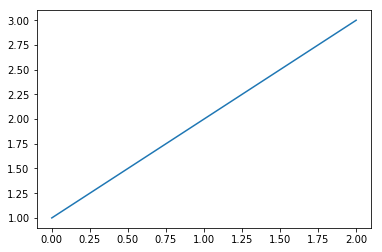

In [3]:
import matplotlib.pyplot as plt
plt.plot([1,2,3])
plt.show()

Building Initial Maze Graph: 100%|██████████| 1521/1521 [00:00<00:00, 2320.19it/s]


Graph Pruning: Kept 1521 nodes (Largest Component) out of 1521 initial valid nodes.


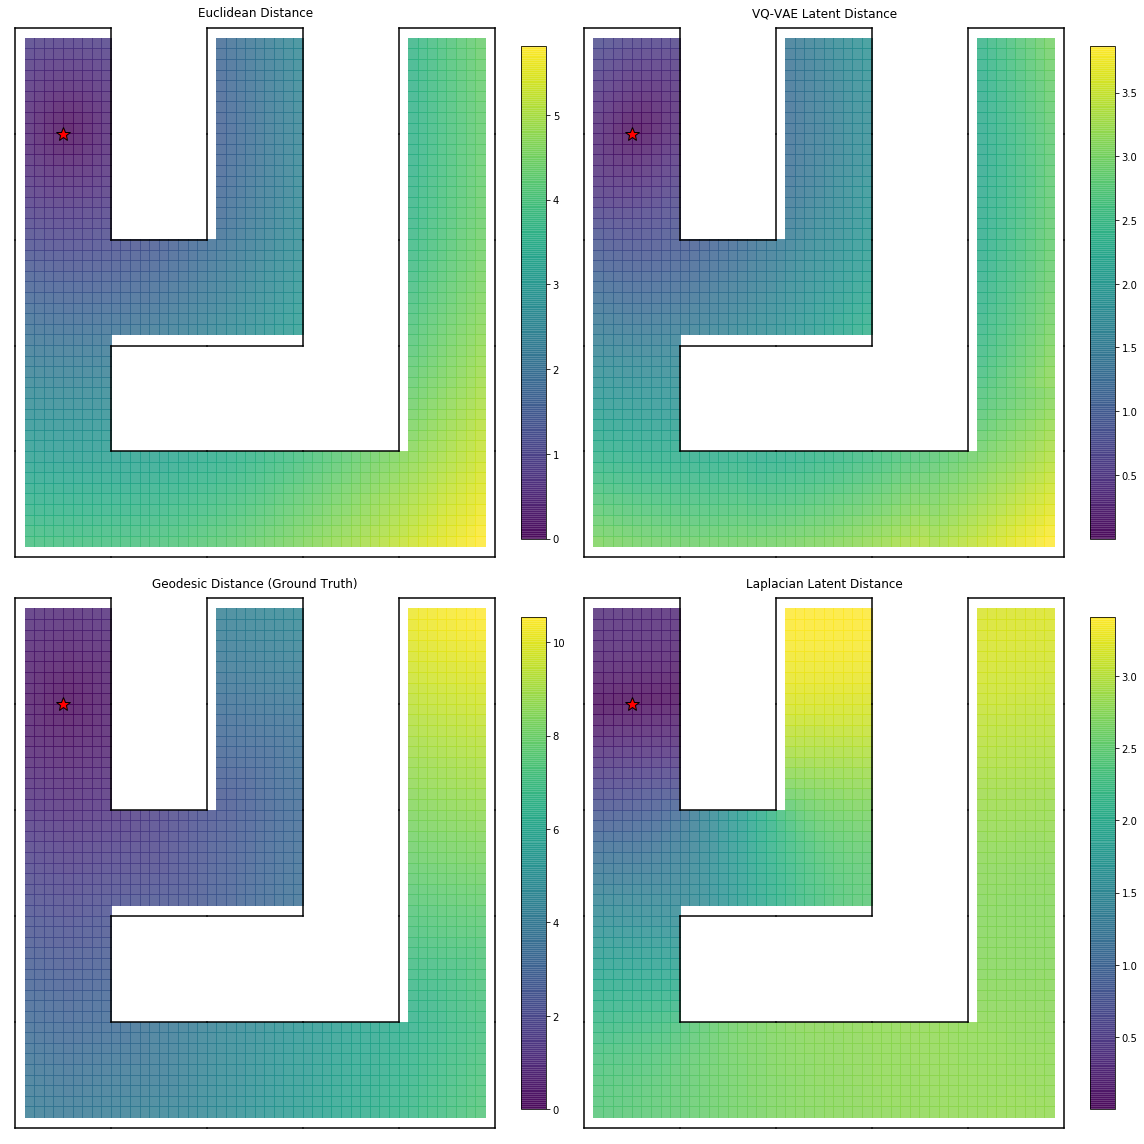

In [4]:
import torch
import numpy as np
import sys, os

# Add the project root to the Python path to allow imports from the agents module
sys.path.append("..")
os.environ["ROOT_DIR"] = ".."  # this allows to use relative paths in config files

from result_inspection.experiment import Experiment
from result_inspection.toy_maze_geodesic import *

exp_name = "square_maze/edl_oracle"
exp = Experiment(exp_name)

# 1. 모델 및 계산기 준비
phi_encoder = load_laplacian_encoder(maze_type="square_a")
geo_calc = GeodesicDistanceCalculator(exp.learner.agent.env.maze,
maze_type="square_a", resolution=0.1)
vae = exp.learner.vae
# 2. Metric 함수 정의
def metric_euclidean(S, s0):
    S_t = torch.tensor(S, dtype=torch.float32)
    s0_t = torch.tensor(s0, dtype=torch.float32).unsqueeze(0)
    return torch.norm(S_t - s0_t, dim=1).detach().numpy()
def metric_vqvae(S, s0):
    S_t = torch.tensor(S, dtype=torch.float32)
    s0_t = torch.tensor(s0, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        z_S = vae.encoder(S_t)
        z_s0 = vae.encoder(s0_t)
    return torch.norm(z_S - z_s0, dim=1).detach().numpy()
def metric_laplacian(S, s0):
    S_t = torch.tensor(S, dtype=torch.float32)
    s0_t = torch.tensor(s0, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        phi_S = phi_encoder(S_t)
        phi_s0 = phi_encoder(s0_t)
    return torch.norm(phi_S - phi_s0, dim=1).detach().numpy()
def metric_geodesic(S, s0):
    # This might be slow if we call get_shortest_path for every point one one.
    # But for heatmap visualization, we can use the pre-computed Dijkstra matrix if we snap points to grid.
    # The helper function handles iteration or batching?
    # visualize_distance_heatmap passes (N, 2) array.
    dists = []
    # Optimization: Use Dijkstra one-to-all from s0 if possible, 
    # but our current API is one-to-one. Let's iterate for now (might be slow).
    # Or better: Use geo_calc internal matrix.
    # Let's use the slow iterative way first for correctness, or optimize needed.
    # To optimize: s0_node_idx = geo_calc.coord_to_node[...] -> row of dist_matrix
    s0_grid = geo_calc._get_grid_coords(s0)
    if s0_grid not in geo_calc.coord_to_node:
        return np.full(len(S), np.nan)
    s0_idx = geo_calc.coord_to_node[s0_grid]
    # Get all distances from s0 using the pre-computed matrix
    # But S points might not align perfectly with graph nodes.
    # We should snap S points to nearest nodes.
    for p in S:
        p_grid = geo_calc._get_grid_coords(p)
        if p_grid in geo_calc.coord_to_node:
            p_idx = geo_calc.coord_to_node[p_grid]
            d = geo_calc.dist_matrix[s0_idx, p_idx]
            dists.append(d)
        else:
            dists.append(np.nan)
    return np.array(dists)
# 3. 기준점 설정
s0 = (0.0, -0.5) # Example start point
# 4. 시각화 (4개 서브플롯)
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()
metrics = [
    (metric_euclidean, "Euclidean Distance"),
    (metric_vqvae, "VQ-VAE Latent Distance"),
    (metric_geodesic, "Geodesic Distance (Ground Truth)"),
    (metric_laplacian, "Laplacian Latent Distance")
]
for ax, (fn, title) in zip(axes, metrics):
    visualize_distance_heatmap(exp, fn, s0=s0, ax=ax, resolution=0.1,
title=title)
plt.tight_layout()
plt.show()
